# **1. Perkenalan Dataset**

Dataset yang digunakan pada eksperimen ini adalah **Iris Dataset**, salah satu dataset klasik dalam machine learning.

### Informasi Dataset
- **Sumber**: Scikit-Learn built-in dataset (berasal dari UCI ML Repository)
- **Jumlah Data**: 150 sampel
- **Jumlah Fitur**: 4 fitur numerik
- **Target**: 3 kelas (Setosa, Versicolor, Virginica)

### Fitur-fitur:
| No | Fitur | Deskripsi |
|----|-------|----------|
| 1 | sepal length (cm) | Panjang kelopak bunga |
| 2 | sepal width (cm) | Lebar kelopak bunga |
| 3 | petal length (cm) | Panjang mahkota bunga |
| 4 | petal width (cm) | Lebar mahkota bunga |

### Tujuan:
Mengklasifikasikan spesies bunga Iris berdasarkan 4 fitur di atas menggunakan model Machine Learning.

# **2. Import Library**

Import pustaka Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
# Library untuk manipulasi data
import pandas as pd
import numpy as np

# Library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Library untuk dataset
from sklearn.datasets import load_iris

# Setting visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

import warnings
warnings.filterwarnings('ignore')

print('Semua library berhasil di-import!')

Semua library berhasil di-import!


# **3. Memuat Dataset**

Memuat dataset Iris dari Scikit-Learn dan mengonversinya menjadi DataFrame Pandas. Dataset juga disimpan sebagai file CSV mentah.

In [2]:
# Load dataset Iris dari sklearn
iris = load_iris()

# Konversi ke DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Simpan sebagai raw CSV
import os
os.makedirs('../iris_raw', exist_ok=True)
df.to_csv('../iris_raw/iris_raw.csv', index=False)
print('Dataset berhasil disimpan ke ../iris_raw/iris_raw.csv')

# Tampilkan informasi dasar
print(f'\nJumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')
print(f'\n5 baris pertama:')
df.head()

Dataset berhasil disimpan ke ../iris_raw/iris_raw.csv

Jumlah baris: 150
Jumlah kolom: 5

5 baris pertama:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Cek informasi dataset
print('=== Informasi Dataset ===')
df.info()

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
# Cek distribusi target
print('=== Distribusi Kelas Target ===')
print(df['species'].value_counts())
print(f'\nDataset seimbang: setiap kelas memiliki 50 sampel.')

=== Distribusi Kelas Target ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Dataset seimbang: setiap kelas memiliki 50 sampel.


# **4. Exploratory Data Analysis (EDA)**

Melakukan Exploratory Data Analysis (EDA) untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
# 4.1 Statistik Deskriptif
print('=== Statistik Deskriptif ===')
df.describe()

=== Statistik Deskriptif ===


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
# 4.2 Cek Missing Values
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

=== Missing Values ===
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Total missing values: 0


In [7]:
# 4.3 Cek Data Duplikat
duplicates = df.duplicated().sum()
print(f'Jumlah data duplikat: {duplicates}')
if duplicates > 0:
    print('Data duplikat ditemukan, akan ditangani pada tahap preprocessing.')

Jumlah data duplikat: 1
Data duplikat ditemukan, akan ditangani pada tahap preprocessing.


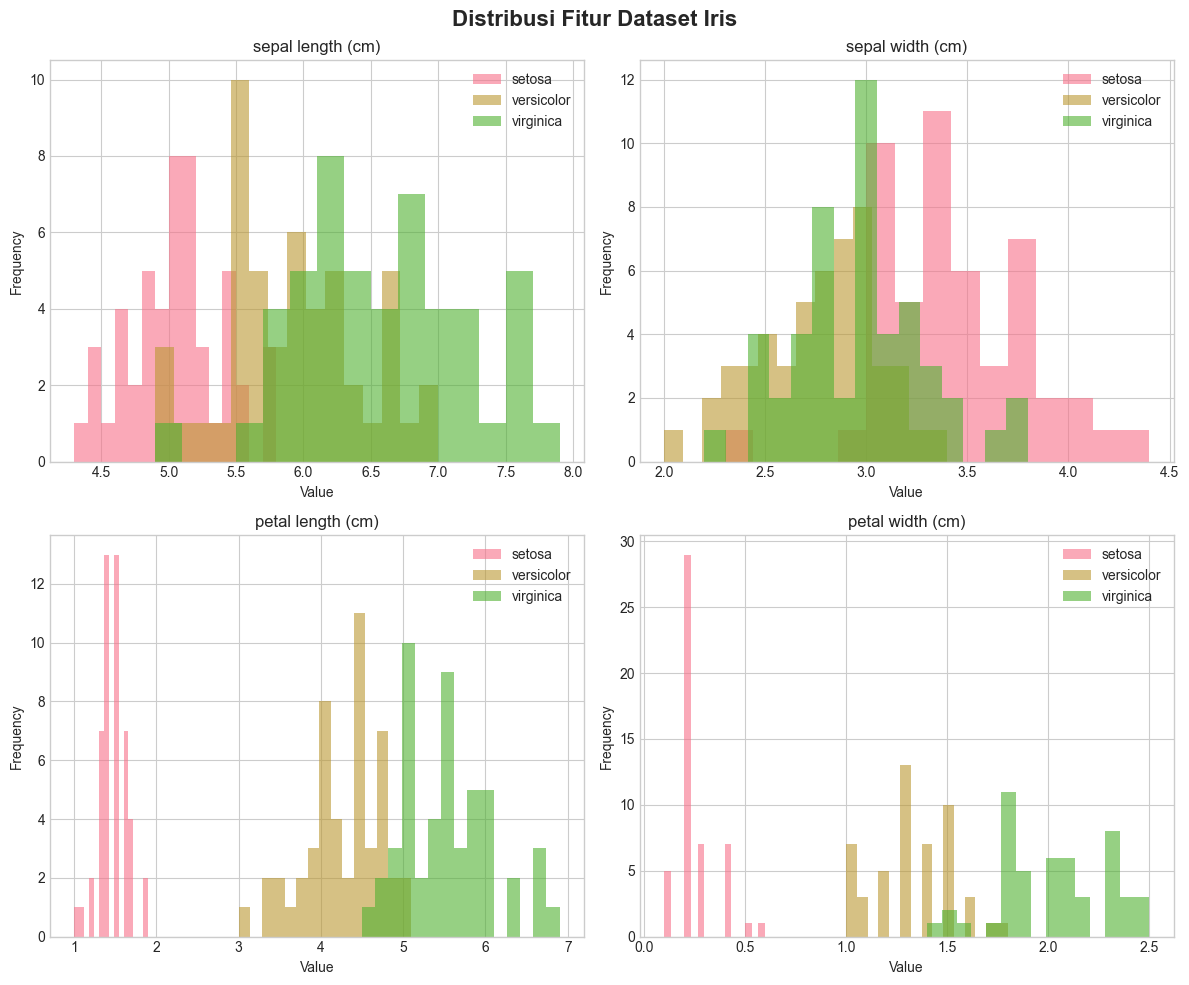

In [8]:
# 4.4 Distribusi Fitur - Histogram
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribusi Fitur Dataset Iris', fontsize=16, fontweight='bold')

feature_cols = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (col, color) in enumerate(zip(feature_cols, colors)):
    ax = axes[idx // 2, idx % 2]
    for species in df['species'].unique():
        subset = df[df['species'] == species]
        ax.hist(subset[col], alpha=0.6, bins=15, label=species)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

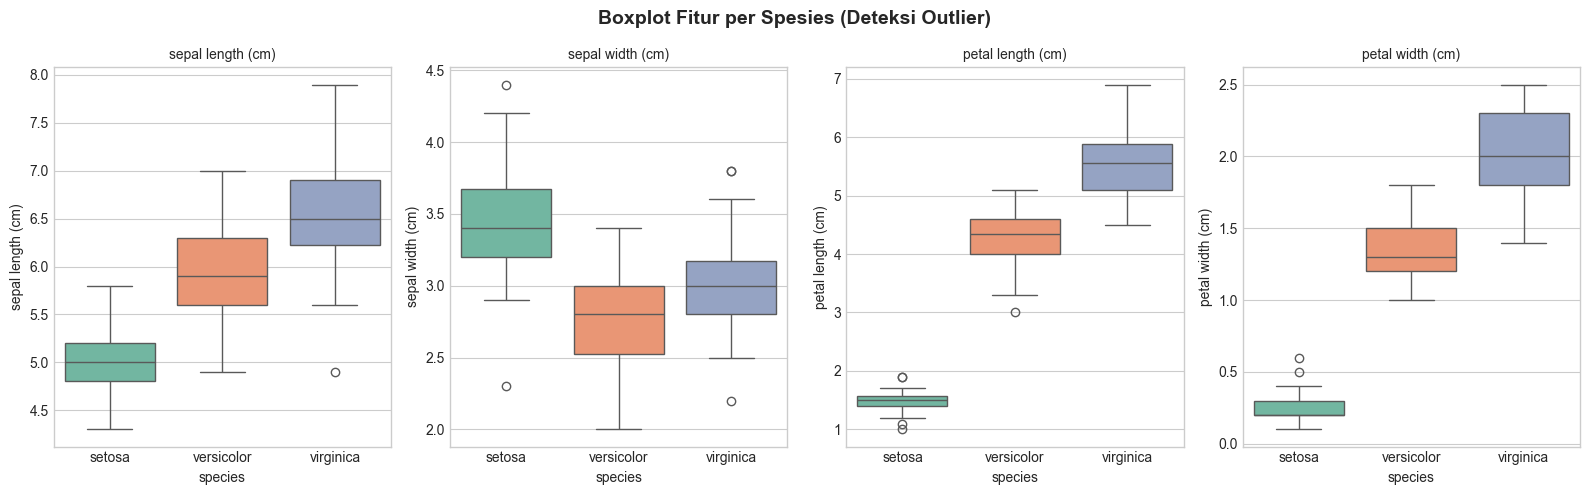

In [9]:
# 4.5 Boxplot - Deteksi Outlier
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Boxplot Fitur per Spesies (Deteksi Outlier)', fontsize=14, fontweight='bold')

for idx, col in enumerate(feature_cols):
    sns.boxplot(x='species', y=col, data=df, ax=axes[idx], palette='Set2')
    axes[idx].set_title(col, fontsize=10)

plt.tight_layout()
plt.show()

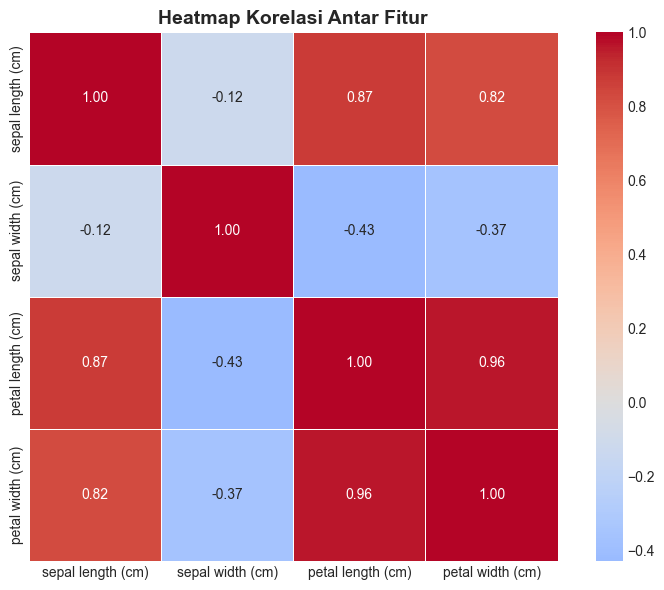

Insight:
- Petal length dan petal width memiliki korelasi sangat tinggi (0.96)
- Sepal length berkorelasi kuat dengan petal length (0.87) dan petal width (0.82)


In [10]:
# 4.6 Heatmap Korelasi
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Insight:')
print('- Petal length dan petal width memiliki korelasi sangat tinggi (0.96)')
print('- Sepal length berkorelasi kuat dengan petal length (0.87) dan petal width (0.82)')

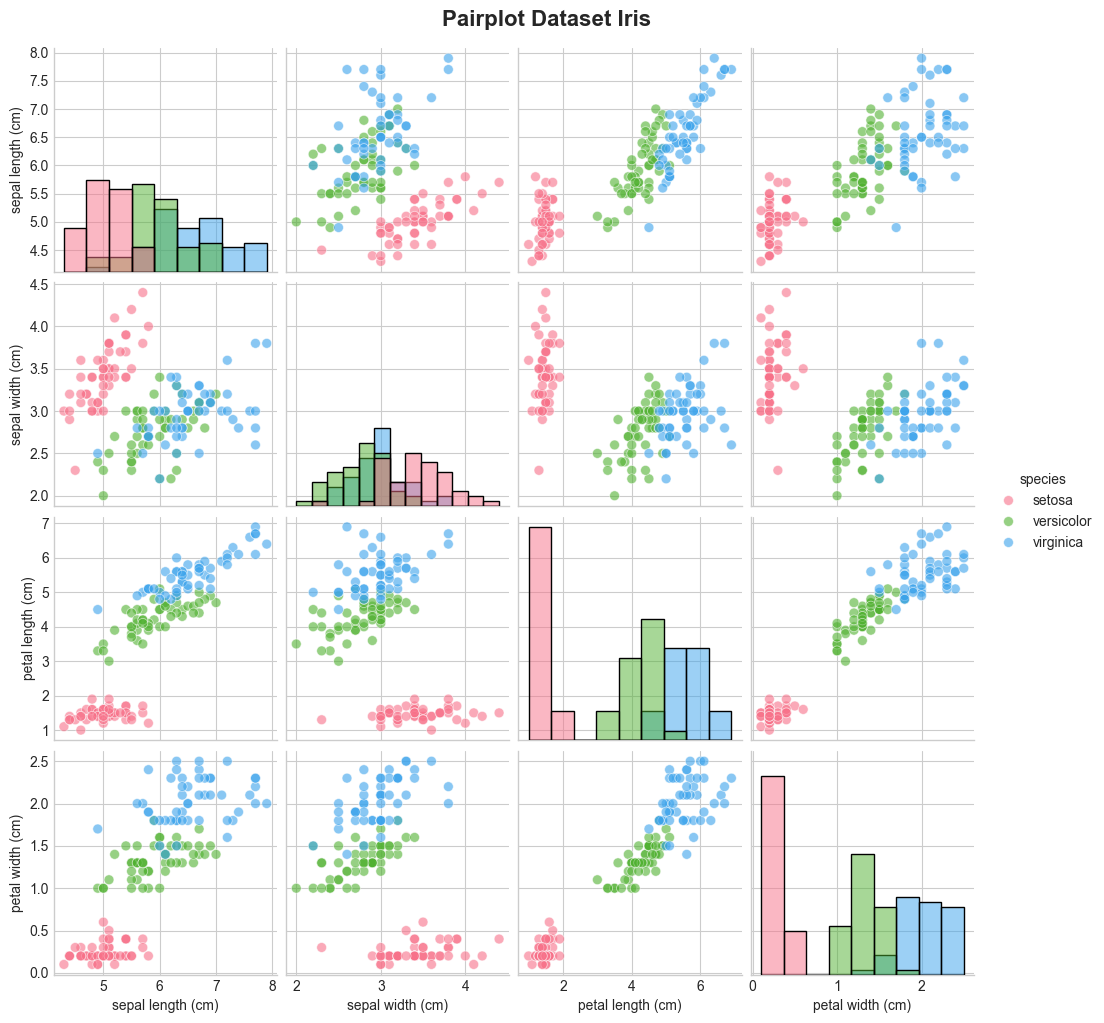

Insight:
- Setosa terpisah jelas dari Versicolor dan Virginica
- Versicolor dan Virginica memiliki overlap pada beberapa fitur


In [11]:
# 4.7 Pairplot
sns.pairplot(df, hue='species', palette='husl', diag_kind='hist',
             plot_kws={'alpha': 0.6, 's': 50})
plt.suptitle('Pairplot Dataset Iris', y=1.02, fontsize=16, fontweight='bold')
plt.show()

print('Insight:')
print('- Setosa terpisah jelas dari Versicolor dan Virginica')
print('- Versicolor dan Virginica memiliki overlap pada beberapa fitur')

# **5. Data Preprocessing**

Tahapan preprocessing yang dilakukan:
1. Menghapus data duplikat
2. Menangani missing values
3. Encoding data kategorikal (LabelEncoder)
4. Normalisasi/Standarisasi fitur (StandardScaler)
5. Train-test split
6. Menyimpan dataset yang sudah dipreproses

In [12]:
# 5.1 Copy dataset untuk preprocessing
df_prep = df.copy()
print(f'Shape awal: {df_prep.shape}')

Shape awal: (150, 5)


In [13]:
# 5.2 Hapus Data Duplikat
before = df_prep.shape[0]
df_prep.drop_duplicates(inplace=True)
after = df_prep.shape[0]
print(f'Data sebelum hapus duplikat: {before}')
print(f'Data setelah hapus duplikat: {after}')
print(f'Data duplikat yang dihapus: {before - after}')

Data sebelum hapus duplikat: 150
Data setelah hapus duplikat: 149
Data duplikat yang dihapus: 1


In [14]:
# 5.3 Tangani Missing Values
missing_before = df_prep.isnull().sum().sum()
df_prep.dropna(inplace=True)
print(f'Missing values ditemukan: {missing_before}')
print(f'Missing values setelah penanganan: {df_prep.isnull().sum().sum()}')
print(f'Shape setelah penanganan: {df_prep.shape}')

Missing values ditemukan: 0
Missing values setelah penanganan: 0
Shape setelah penanganan: (149, 5)


In [15]:
# 5.4 Encoding Data Kategorikal
le = LabelEncoder()
df_prep['species_encoded'] = le.fit_transform(df_prep['species'])

print('Mapping Label Encoding:')
for i, label in enumerate(le.classes_):
    print(f'  {label} -> {i}')

print(f'\nDistribusi setelah encoding:')
print(df_prep['species_encoded'].value_counts().sort_index())

Mapping Label Encoding:
  setosa -> 0
  versicolor -> 1
  virginica -> 2

Distribusi setelah encoding:
species_encoded
0    50
1    50
2    49
Name: count, dtype: int64


In [16]:
# 5.5 Normalisasi / Standarisasi Fitur
scaler = StandardScaler()
df_prep[feature_cols] = scaler.fit_transform(df_prep[feature_cols])

print('Fitur setelah StandardScaler:')
print(f'Mean (mendekati 0):')
print(df_prep[feature_cols].mean().round(4))
print(f'\nStd (mendekati 1):')
print(df_prep[feature_cols].std().round(4))

print(f'\n5 baris pertama setelah standarisasi:')
df_prep.head()

Fitur setelah StandardScaler:
Mean (mendekati 0):
sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)   -0.0
petal width (cm)    -0.0
dtype: float64

Std (mendekati 1):
sepal length (cm)    1.0034
sepal width (cm)     1.0034
petal length (cm)    1.0034
petal width (cm)     1.0034
dtype: float64

5 baris pertama setelah standarisasi:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_encoded
0,-0.898033,1.012401,-1.333255,-1.308624,setosa,0
1,-1.139562,-0.137353,-1.333255,-1.308624,setosa,0
2,-1.381091,0.322549,-1.390014,-1.308624,setosa,0
3,-1.501855,0.092598,-1.276496,-1.308624,setosa,0
4,-1.018798,1.242352,-1.333255,-1.308624,setosa,0


In [17]:
# 5.6 Simpan dataset yang sudah dipreproses
df_final = df_prep.drop(columns=['species'])

os.makedirs('iris_preprocessing', exist_ok=True)
df_final.to_csv('iris_preprocessing/iris_preprocessed.csv', index=False)

print(f'Dataset preprocessed berhasil disimpan!')
print(f'Path: iris_preprocessing/iris_preprocessed.csv')
print(f'Shape: {df_final.shape}')
print(f'\nKolom: {list(df_final.columns)}')
print(f'\n5 baris pertama data final:')
df_final.head()

Dataset preprocessed berhasil disimpan!
Path: iris_preprocessing/iris_preprocessed.csv
Shape: (149, 5)

Kolom: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species_encoded']

5 baris pertama data final:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_encoded
0,-0.898033,1.012401,-1.333255,-1.308624,0
1,-1.139562,-0.137353,-1.333255,-1.308624,0
2,-1.381091,0.322549,-1.390014,-1.308624,0
3,-1.501855,0.092598,-1.276496,-1.308624,0
4,-1.018798,1.242352,-1.333255,-1.308624,0


In [18]:
# 5.7 Verifikasi Train-Test Split
X = df_final.drop(columns=['species_encoded'])
y = df_final['species_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('=== Train-Test Split ===')
print(f'Total data: {len(X)}')
print(f'Training set: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nDistribusi target di training set:')
print(y_train.value_counts().sort_index())
print(f'\nDistribusi target di test set:')
print(y_test.value_counts().sort_index())

print('\n✅ Data siap untuk digunakan pada tahap modelling!')

=== Train-Test Split ===
Total data: 149
Training set: 119 (80%)
Test set: 30 (20%)

Distribusi target di training set:
species_encoded
0    40
1    40
2    39
Name: count, dtype: int64

Distribusi target di test set:
species_encoded
0    10
1    10
2    10
Name: count, dtype: int64

✅ Data siap untuk digunakan pada tahap modelling!
